# Model Building Process — Boy or Girl 2025

## Overview
- **Data Leakage Fix** — `OrdinalEncoder` fitted on training set only; unknown categories mapped to `-1`.
- **`self_intro` Text Features** — 8 features extracted: character count, word count, uppercase ratio, punctuation density, capitalization pattern, etc.
- **VotingEnsemble Fix** — Untrained estimators passed to `VotingClassifier`; `.fit()` handled internally.
- **CatBoost** — Native categorical support, no encoding required.
- **Stacking Ensemble** — XGB + LGB + RF + CatBoost → Logistic Regression (meta-learner).
- **Outlier Tagging** — `sleepiness` and `yt` outlier flags completed.

In [1]:
import os, re, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score)
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, VotingClassifier,
                              StackingClassifier)
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             confusion_matrix, roc_curve, auc,
                             classification_report)
from sklearn.base import BaseEstimator, TransformerMixin

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost not installed: pip install xgboost")

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print("LightGBM not installed: pip install lightgbm")

try:
    from catboost import CatBoostClassifier
    HAS_CAT = True
except ImportError:
    HAS_CAT = False
    print("CatBoost not installed: pip install catboost")

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'Arial Unicode MS', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

DATA_DIR = Path('./data')
TRAIN_PATH = DATA_DIR / 'boy or girl 2025 train_missingValue.csv'
TEST_PATH  = DATA_DIR / 'boy or girl 2025 test no ans_missingValue.csv'

if TRAIN_PATH.exists() and TEST_PATH.exists():
    df_train = pd.read_csv(TRAIN_PATH)
    df_test  = pd.read_csv(TEST_PATH)
    print(f"Train shape: {df_train.shape}")
    print(f"Test  shape: {df_test.shape}")
else:
    raise FileNotFoundError(f"Data files not found, please check the paths:\n{TRAIN_PATH}\n{TEST_PATH}")


Train shape: (423, 11)
Test  shape: (426, 11)


## 1. Exploratory Data Analysis (EDA)

- **Class Distribution** — Inspect target label balance and compute imbalance ratio.
- **Missing Values** — Identify columns with null entries and their percentage.
- **Feature Overview** — Review data types, value ranges, and categorical cardinalities.

In [2]:
print("=" * 70)
print("Basic Overview")
print("=" * 70)
print(df_train.head())
print()
print("Target Variable Distribution:")
print(df_train['gender'].value_counts())
ratio = df_train['gender'].value_counts()
print(f"Imbalance Ratio: {ratio[1]}:{ratio[2]} = {ratio[1]/ratio[2]:.2f}:1")

print()
print("Missing Values Statistics:")
miss = df_train.isnull().sum()
miss_pct = miss / len(df_train) * 100
print(pd.DataFrame({'count': miss, 'pct%': miss_pct.round(1)})[miss > 0])


Basic Overview
   id  gender star_sign phone_os  height  weight  sleepiness     iq  \
0   1       2       處女座    Apple   154.0    43.0         NaN    NaN   
1   2       2       處女座    Apple   156.0    47.0         NaN  130.0   
2   3       1       射手座      NaN   170.0    61.0         NaN   90.0   
3   4       1       射手座    Apple   170.0    62.0         4.0  100.0   
4   5       2       射手座  Android   158.0    67.0         NaN  128.0   

   fb_friends   yt                     self_intro  
0       583.0    0                      Beautiful  
1         NaN  3.5  Enjoying being who I'm notsss  
2       540.0  NaN         Practice Makes perfect  
3         NaN    5                Straightforward  
4       320.0  1.2                       Humorous  

Target Variable Distribution:
gender
1    316
2    107
Name: count, dtype: int64
Imbalance Ratio: 316:107 = 2.95:1

Missing Values Statistics:
            count  pct%
star_sign      86  20.3
phone_os       78  18.4
height         74  17.5
weight

## 2. Feature Engineering

- **`self_intro` Text Features** — 8 features extracted to capture writing style differences.
- **`sleepiness` / `yt` Outlier Tagging** — Extreme values flagged as binary indicator columns.
- **`yt` Type Correction** — Original string field cast to float.
- All logic encapsulated in `FeatureEngineer`; `.fit()` called on training data only.

In [3]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Feature engineering transformer.
    fit() does not learn any statistics (all rules are hard rules),
    thus fit_transform(X_train) and transform(X_test) have consistent behavior,
    no risk of data leakage.
    """
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # ── A. Type Correction ──────────────────────────────────────────
        num_cols = ['height', 'weight', 'sleepiness', 'iq', 'fb_friends', 'yt']
        for col in num_cols:
            X[col] = pd.to_numeric(X[col], errors='coerce')

        # ── B. Missing Value Indicator (done first to avoid NaN override) 
        miss_cols = ['height', 'weight', 'sleepiness', 'iq',
                     'fb_friends', 'yt', 'star_sign', 'phone_os', 'self_intro']
        for col in miss_cols:
            X[f'{col}_is_missing'] = X[col].isnull().astype(int)

        # ── C. Outlier Indicator (completeness for sleepiness/yt) ───────
        X['height_is_anomaly']     = ((X['height'] < 140) | (X['height'] > 200)).astype(int)
        X['weight_is_anomaly']     = ((X['weight'] < 35)  | (X['weight'] > 120)).astype(int)
        X['iq_is_anomaly']         = ((X['iq'] < 50)      | (X['iq'] > 180)).astype(int)
        X['fb_friends_is_anomaly'] = (X['fb_friends'] > 5000).astype(int)
        X['sleepiness_is_anomaly'] = ((X['sleepiness'] < 0) | (X['sleepiness'] > 24)).astype(int)
        X['yt_is_anomaly']         = (X['yt'] > 24).astype(int)

        # ── D. Extreme Values to NaN (avoid ruining gradients) ──────────
        X.loc[(X['height'] > 250) | (X['height'] < 100), 'height'] = np.nan
        X.loc[(X['weight'] > 200) | (X['weight'] < 20),  'weight'] = np.nan
        X.loc[X['yt'] > 24, 'yt'] = np.nan

        # ── E. Basic Derived Features ───────────────────────────────────
        h_m = X['height'] / 100
        X['bmi'] = (X['weight'] / (h_m ** 2)).replace([np.inf, -np.inf], np.nan)

        X['social_activity'] = (X['fb_friends'].fillna(0)
                                + X['yt'].fillna(0) * 100)

        # ── F. Star Sign Elements (Dimensions Reduction) ────────────────
        fire  = {'白羊', '牡羊', '獅子', '射手'} # Aries, Leo, Sagittarius
        water = {'巨蟹', '天蠍', '雙魚'} # Cancer, Scorpio, Pisces
        air   = {'雙子', '天秤', '水瓶'} # Gemini, Libra, Aquarius
        earth = {'金牛', '處女', '摩羯', '魔羯'} # Taurus, Virgo, Capricorn

        def _element(sign):
            if pd.isna(sign): return 'unknown'
            s = str(sign).replace('座', '')
            if s in fire:  return 'fire'
            if s in water: return 'water'
            if s in air:   return 'air'
            if s in earth: return 'earth'
            return 'unknown'

        X['star_element'] = X['star_sign'].apply(_element)

        # ── G. self_intro Text Feature Enhancement (8 new features) ─────
        def _text_features(text):
            if pd.isna(text) or str(text).strip() == '':
                return {
                    'intro_len': 0, 'intro_word_count': 0,
                    'intro_upper_ratio': 0.0, 'intro_lower_ratio': 0.0,
                    'intro_has_punct': 0, 'intro_has_number': 0,
                    'intro_title_case': 0, 'intro_has_chinese': 0
                }
            t = str(text)
            alpha = [c for c in t if c.isalpha()]
            return {
                'intro_len':         len(t),
                'intro_word_count':  len(t.split()),
                'intro_upper_ratio': sum(1 for c in alpha if c.isupper()) / max(len(alpha), 1),
                'intro_lower_ratio': sum(1 for c in alpha if c.islower()) / max(len(alpha), 1),
                'intro_has_punct':   int(bool(re.search(r'[!?.,;:~]', t))),
                'intro_has_number':  int(bool(re.search(r'\d', t))),
                'intro_title_case':  int(t.istitle()),
                'intro_has_chinese': int(bool(re.search(r'[\u4e00-\u9fff]', t)))
            }

        text_feats = X['self_intro'].apply(_text_features).apply(pd.Series)
        X = pd.concat([X, text_feats], axis=1)

        # ── H. Aggregate Metrics ────────────────────────────────────────
        X['total_anomaly_score'] = (
            X['height_is_anomaly'] + X['weight_is_anomaly'] +
            X['iq_is_anomaly'] + X['fb_friends_is_anomaly'] +
            X['sleepiness_is_anomaly'] + X['yt_is_anomaly']
        )
        miss_ind_cols = [c for c in X.columns if c.endswith('_is_missing')]
        X['total_missing_count'] = X[miss_ind_cols].sum(axis=1)

        return X

print("FeatureEngineer definition complete.")

FeatureEngineer definition complete.


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline

# Fix: Define pipeline only, do not fit here.
# Moved fit after train/val split, fit only using text from train fold,
# Prevents val fold data from affecting TF-IDF vocabulary & SVD space.
N_SVD_COMPONENTS = 8
svd_cols = [f'svd_intro_{i}' for i in range(N_SVD_COMPONENTS)]

tfidf_svd_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(
        analyzer='char_wb',
        ngram_range=(2, 4),
        max_features=300,
        sublinear_tf=True
    )),
    ('svd', TruncatedSVD(n_components=N_SVD_COMPONENTS, random_state=RANDOM_SEED))
])

# Store raw text (NaN -> empty string), fit after splitting
train_intro_full = df_train['self_intro'].fillna('').astype(str)
test_intro_full  = df_test['self_intro'].fillna('').astype(str)

print(f"TF-IDF SVD pipeline definition complete (wait for split to fit, avoiding leakage)")
print(f"self_intro: train={len(train_intro_full)} | test={len(test_intro_full)}")


TF-IDF SVD pipeline definition complete (wait for split to fit, avoiding leakage)
self_intro: train=423 | test=426


## 3. Data Preprocessing & Encoding

### Data Leakage Fix
Previous pipeline fitted `LabelEncoder` on train + test combined.
Replaced with `OrdinalEncoder`, **fitted on training set only**;
unknown test categories assigned `-1`.

In [5]:
X_raw      = df_train.drop(columns=['id', 'gender'])
y          = df_train['gender']
X_test_raw = df_test.drop(columns=['id', 'gender'], errors='ignore')

# ── Feature Engineering ─────────────────────────────────────────
fe = FeatureEngineer()
X_eng      = fe.fit_transform(X_raw)
X_test_eng = fe.transform(X_test_raw)

print(f"Raw Features Count: {X_raw.shape[1]}")
print(f"After Feature Engineering: {X_eng.shape[1]}")
new_feats = [c for c in X_eng.columns if c not in X_raw.columns]
print(f"New Features Added ({len(new_feats)}):")
for f in new_feats:
    print(f"  - {f}")

# ── Categorical Encoding ────────────────────────────────────────
cat_cols = ['star_sign', 'star_element', 'phone_os']

X_proc      = X_eng.copy()
X_test_proc = X_test_eng.copy()

oe = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1,
    dtype=np.float32
)
for col in cat_cols:
    X_proc[[col]]      = oe.fit_transform(X_proc[[col]].fillna('__MISSING__'))
    X_test_proc[[col]] = oe.transform(X_test_proc[[col]].fillna('__MISSING__'))
    print(f"  ✓ {col}")

X_proc      = X_proc.drop(columns=['self_intro'], errors='ignore')
X_test_proc = X_test_proc.drop(columns=['self_intro'], errors='ignore')

# ── Numeric Types & Inf Cleanup ─────────────────────────────────
def clean_df(df):
    df = df.replace([np.inf, -np.inf], np.nan)
    for col in df.select_dtypes(include=[np.number]).columns:
        df[col] = df[col].clip(upper=1e10)
    return df

X_proc      = clean_df(X_proc)
X_test_proc = clean_df(X_test_proc)

print(f"After Feature Eng (excl SVD): {X_proc.shape[1]} columns")

# ── Train / Val split ────────────────────────────────────────────────────
X_train_base, X_val_base, y_train, y_val = train_test_split(
    X_proc, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED
)
y_train_bin = (y_train == 2).astype(int)
y_val_bin   = (y_val   == 2).astype(int)

print(f"\nTrain: {X_train_base.shape[0]} | Val: {X_val_base.shape[0]}")
print(f"Train gender dist: {y_train.value_counts().to_dict()}")

# ── TF-IDF SVD: fitted post-split (fixed leakage) ───────────────
import copy as _copy
tfidf_svd_tr = _copy.deepcopy(tfidf_svd_pipe)

tr_intro = train_intro_full.loc[X_train_base.index].values
va_intro = train_intro_full.loc[X_val_base.index].values
te_intro = test_intro_full.values

svd_tr_arr = tfidf_svd_tr.fit_transform(tr_intro)
svd_va_arr = tfidf_svd_tr.transform(va_intro)
svd_te_arr = tfidf_svd_tr.transform(te_intro)

df_svd_tr = pd.DataFrame(svd_tr_arr, columns=svd_cols)
df_svd_va = pd.DataFrame(svd_va_arr, columns=svd_cols)
df_svd_te = pd.DataFrame(svd_te_arr, columns=svd_cols)

X_train = pd.concat([X_train_base.reset_index(drop=True), df_svd_tr], axis=1)
X_val   = pd.concat([X_val_base.reset_index(drop=True),   df_svd_va], axis=1)
X_test_proc = pd.concat([X_test_proc.reset_index(drop=True), df_svd_te], axis=1)

# X_proc for Optuna/cross_val_score: SVD fit on ALL training data
svd_all_arr = tfidf_svd_pipe.fit_transform(train_intro_full.values)
df_svd_all  = pd.DataFrame(svd_all_arr, columns=svd_cols)
X_proc = pd.concat([X_proc.reset_index(drop=True), df_svd_all], axis=1)

print(f"After Adding SVD: {X_train.shape[1]} columns")

# ── KFoldTargetEncoder class definition ─────────────────────────
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import KFold
from sklearn.impute import SimpleImputer

class KFoldTargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, cols, n_splits=5, random_state=42):
        self.cols = cols
        self.n_splits = n_splits
        self.random_state = random_state
        self.global_means_ = {}
        self.overall_mean_ = None

    def fit(self, X, y):
        X = pd.DataFrame(X).copy()
        y = pd.Series(y).reset_index(drop=True)
        self.overall_mean_ = y.mean()
        for col in self.cols:
            self.global_means_[col] = (
                y.groupby(X[col].fillna('__NaN__').values).mean()
            )
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for col in self.cols:
            X[col] = (X[col].fillna('__NaN__')
                       .map(self.global_means_[col])
                       .fillna(self.overall_mean_))
        return X

# ── Imputation & SMOTE ───────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE

y_bin_all = (y == 2).astype(int)

imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns
)
X_val_imputed = pd.DataFrame(
    imputer.transform(X_val),
    columns=X_val.columns
)

sm = SMOTE(random_state=RANDOM_SEED, k_neighbors=5)
X_train_sm, y_train_sm = sm.fit_resample(X_train_imputed, y_train_bin)
print(f"Before SMOTE - Male: {(y_train_bin==0).sum()}, Female: {(y_train_bin==1).sum()}")
print(f"After SMOTE - Male: {(y_train_sm==0).sum()}, Female: {(y_train_sm==1).sum()}")

Raw Features Count: 9
After Feature Engineering: 37
New Features Added (28):
  - height_is_missing
  - weight_is_missing
  - sleepiness_is_missing
  - iq_is_missing
  - fb_friends_is_missing
  - yt_is_missing
  - star_sign_is_missing
  - phone_os_is_missing
  - self_intro_is_missing
  - height_is_anomaly
  - weight_is_anomaly
  - iq_is_anomaly
  - fb_friends_is_anomaly
  - sleepiness_is_anomaly
  - yt_is_anomaly
  - bmi
  - social_activity
  - star_element
  - intro_len
  - intro_word_count
  - intro_upper_ratio
  - intro_lower_ratio
  - intro_has_punct
  - intro_has_number
  - intro_title_case
  - intro_has_chinese
  - total_anomaly_score
  - total_missing_count
  ✓ star_sign
  ✓ star_element
  ✓ phone_os
After Feature Eng (excl SVD): 36 columns

Train: 338 | Val: 85
Train gender dist: {1: 253, 2: 85}
After Adding SVD: 44 columns
Before SMOTE - Male: 253, Female: 85
After SMOTE - Male: 253, Female: 253


In [6]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
y_bin_all = (y == 2).astype(int)
n_neg = (y_train_bin == 0).sum()
n_pos = (y_train_bin == 1).sum()
scale_pos_weight = n_neg / n_pos

def xgb_objective(trial):
    params = {
        'max_depth':        trial.suggest_int('max_depth', 3, 9),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'n_estimators':     trial.suggest_int('n_estimators', 100, 500, step=50),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'scale_pos_weight': scale_pos_weight,
        'random_state': RANDOM_SEED, 'eval_metric': 'auc',
        'tree_method': 'hist', 'enable_categorical': False
    }
    return cross_val_score(xgb.XGBClassifier(**params), X_proc, y_bin_all,
                           cv=skf, scoring='roc_auc', n_jobs=-1).mean()

study_xgb = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)
)
study_xgb.optimize(xgb_objective, n_trials=100)
print(f"XGBoost Best Params: {study_xgb.best_params}")
print(f"XGBoost Best AUC: {study_xgb.best_value:.4f}")

def lgb_objective(trial):
    params = {
        'max_depth':         trial.suggest_int('max_depth', 3, 12),
        'num_leaves':        trial.suggest_int('num_leaves', 10, 100),
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'n_estimators':      trial.suggest_int('n_estimators', 100, 600, step=50),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'class_weight': 'balanced',
        'random_state': RANDOM_SEED, 'verbose': -1
    }
    return cross_val_score(lgb.LGBMClassifier(**params), X_proc, y_bin_all,
                           cv=skf, scoring='roc_auc', n_jobs=-1).mean()
                           

study_lgb = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)
)
study_lgb.optimize(lgb_objective, n_trials=500)
print(f"LightGBM Best Params: {study_lgb.best_params}")
print(f"LightGBM Best AUC: {study_lgb.best_value:.4f}")

def rf_objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500, step=50),
        'max_depth':         trial.suggest_int('max_depth', 3, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'class_weight': 'balanced',
        'random_state': RANDOM_SEED,
        'n_jobs': -1
    }
    return cross_val_score(RandomForestClassifier(**params), X_proc, y_bin_all,
                           cv=skf, scoring='roc_auc', n_jobs=-1).mean()

study_rf = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)
)
study_rf.optimize(rf_objective, n_trials=500)
print(f"RandomForest Best Params: {study_rf.best_params}")
print(f"RandomForest Best AUC: {study_rf.best_value:.4f}")

XGBoost Best Params: {'max_depth': 9, 'learning_rate': 0.029647385851459516, 'n_estimators': 150, 'min_child_weight': 3, 'subsample': 0.790319952343386, 'colsample_bytree': 0.9334203722408688}
XGBoost Best AUC: 0.9426
LightGBM Best Params: {'max_depth': 10, 'num_leaves': 96, 'learning_rate': 0.030918976695436973, 'n_estimators': 150, 'min_child_samples': 14, 'subsample': 0.5360152874901791, 'colsample_bytree': 0.5873900511946551}
LightGBM Best AUC: 0.9427
RandomForest Best Params: {'n_estimators': 200, 'max_depth': 8, 'min_samples_split': 4, 'min_samples_leaf': 6, 'max_features': None}
RandomForest Best AUC: 0.9355


In [7]:
def cat_objective(trial):
    params = {
        'iterations':    trial.suggest_int('iterations', 100, 400, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'depth':         trial.suggest_int('depth', 3, 8),
        'l2_leaf_reg':   trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'subsample':     trial.suggest_float('subsample', 0.5, 1.0),
        'auto_class_weights': 'Balanced',
        'random_seed': RANDOM_SEED,
        'verbose': 0
    }
    return cross_val_score(CatBoostClassifier(**params), X_proc, y_bin_all,
                           cv=skf, scoring='roc_auc', n_jobs=-1).mean()

study_cat = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)
)
study_cat.optimize(cat_objective, n_trials=50)
print(f"CatBoost Best Params: {study_cat.best_params}")
print(f"CatBoost Best AUC: {study_cat.best_value:.4f}")

CatBoost Best Params: {'iterations': 150, 'learning_rate': 0.015311388551098544, 'depth': 7, 'l2_leaf_reg': 0.9615237375475458, 'subsample': 0.5961887143056945}
CatBoost Best AUC: 0.9344


## 4. Model Definition

- **XGBoost / LightGBM** — Gradient boosting models with Optuna-tuned hyperparameters.
- **Random Forest** — Bagging ensemble with `class_weight='balanced'`.
- **CatBoost** — Natively handles categorical features; no encoding required.
- All models defined as factory functions (`make_xgb()`, `make_lgb()`, etc.) to ensure fresh untrained instances on every call.

In [8]:
from sklearn.utils.class_weight import compute_class_weight

# ── Imbalance weights calc ──────────────────────────────────────
#n_neg = (y_train_bin == 0).sum()   # male (majority)
#n_pos = (y_train_bin == 1).sum()   # female (minority)
#scale_pos_weight = n_neg / n_pos
#print(f"scale_pos_weight: {scale_pos_weight:.3f}  (neg={n_neg}, pos={n_pos})")

# ── Model Definitions (using untrained objects) ─────────────────
def make_xgb():
    return xgb.XGBClassifier(
        max_depth=9,
        learning_rate=0.029647385851459516,
        n_estimators=150,
        min_child_weight=3,
        subsample=0.790319952343386,
        colsample_bytree=0.9334203722408688,
        #scale_pos_weight=scale_pos_weight,
        objective='binary:logistic',
        eval_metric='auc',
        tree_method='hist',
        random_state=RANDOM_SEED,
        enable_categorical=False
    ) if HAS_XGB else None

def make_lgb():
    return lgb.LGBMClassifier(
        max_depth=10,
        num_leaves=96,
        learning_rate=0.030918976695436973,
        n_estimators=150,
        min_child_samples=14,
        subsample=0.5360152874901791,
        colsample_bytree=0.5873900511946551,
        #class_weight='balanced',
        objective='binary',
        metric='auc',
        random_state=RANDOM_SEED,
        verbose=-1
    ) if HAS_LGB else None

def make_rf():
    return RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_split=4,
        min_samples_leaf=6,
        #class_weight='balanced',
        random_state=RANDOM_SEED,
        n_jobs=-1
    )

def make_cat():
    # Fixed: Removed cat_features parameter
    # Categorical columns transformed via K-Fold Target Encoding
    # Hence CatBoost behaves consistently inside Voting/Stacking.
    return CatBoostClassifier(
        iterations=150,
        learning_rate=0.015311388551098544,
        depth=7,
        l2_leaf_reg=0.9615237375475458,
        subsample=0.5961887143056945,
        #auto_class_weights='Balanced',
        eval_metric='AUC',
        random_seed=RANDOM_SEED,
        verbose=0
    ) if HAS_CAT else None

print("Model factory functions definition complete.")


Model factory functions definition complete.


## 5. Train Individual Base Models

Each model is trained on the SMOTE-resampled training set and evaluated on the held-out validation set.
- **XGBoost / LightGBM** — Gradient boosting with early stopping via eval set.
- **Random Forest** — Bagging ensemble with balanced class weights.
- **CatBoost** — Trained with `auto_class_weights='Balanced'`; no encoding needed.

In [ ]:
trained_models = {}

# ── XGBoost ──────────────────────────────────────────────────────────────
if HAS_XGB:
    print("[1/4] Training XGBoost...")
    xgb_model = make_xgb()
    xgb_model.fit(X_train_sm, y_train_sm,
                  eval_set=[(X_val_imputed, y_val_bin)],   # ← Changed here
                  verbose=False)

    trained_models['XGBoost'] = xgb_model
    print("  ✓ Complete")
else:
    print("[1/4] XGBoost not installed, skipping")

# ── LightGBM ─────────────────────────────────────────────────────────────
if HAS_LGB:
    print("[2/4] Training LightGBM...")
    lgb_model = make_lgb()
    lgb_model.fit(X_train_sm, y_train_sm,
                  eval_set=[(X_val_imputed, y_val_bin)],   # ← Changed here
                  callbacks=[lgb.early_stopping(50, verbose=False),
                             lgb.log_evaluation(-1)])
    trained_models['LightGBM'] = lgb_model
    print("  ✓ Complete")
else:
    print("[2/4] LightGBM not installed, skipping")

# ── Random Forest ─────────────────────────────────────────────────────────
print("[3/4] Training Random Forest...")
rf_model = make_rf()
rf_model.fit(X_train_sm, y_train_sm)
trained_models['RandomForest'] = rf_model
print("  ✓ Complete")

# ── CatBoost ─────────────────────────────────────────────────────────────
if HAS_CAT:
    print("[4/4] Training CatBoost...")
    cat_model = make_cat()
    cat_model.fit(X_train_sm, y_train_sm,
                  eval_set=(X_val_imputed, y_val_bin))
    trained_models['CatBoost'] = cat_model
    print("  ✓ Complete")
else:
    print("[4/4] CatBoost not installed, skipping")

print(f"\nTrained Models: {list(trained_models.keys())}")


[1/4] Training XGBoost...
  ✓ Complete
[2/4] Training LightGBM...
  ✓ Complete
[3/4] Training Random Forest...
  ✓ Complete
[4/4] Training CatBoost...
  ✓ Complete

Trained Models: ['XGBoost', 'LightGBM', 'RandomForest', 'CatBoost']


## 6. Voting Ensemble

Untrained estimators passed via `make_xxx()`; `VotingClassifier` calls `.fit()` once internally — double-fitting issue resolved.

In [ ]:
print("Creating Voting Ensemble (soft voting)...")

estimators_for_voting = []
if HAS_XGB: estimators_for_voting.append(('xgb', make_xgb()))
if HAS_LGB: estimators_for_voting.append(('lgb', make_lgb()))
estimators_for_voting.append(('rf', make_rf()))
if HAS_CAT: estimators_for_voting.append(('cat', make_cat()))

voting_clf = VotingClassifier(
    estimators=estimators_for_voting,
    voting='soft',
    n_jobs=-1
)
voting_clf.fit(X_train_sm, y_train_sm)
trained_models['VotingEnsemble'] = voting_clf
print("  ✓ Voting Ensemble training complete")


Creating Voting Ensemble (soft voting)...
  ✓ Voting Ensemble training complete


## 7. Stacking Ensemble

**Architecture**:
- Base learners (Level-0): XGBoost + LightGBM + Random Forest + CatBoost
- Meta-learner (Level-1): Logistic Regression (`passthrough=True`)

`StackingClassifier` uses out-of-fold predictions to train the meta-learner — base learners never predict on their own training data, no leakage.

In [ ]:
print("Creating Stacking Ensemble...")

stack_estimators = []
if HAS_XGB: stack_estimators.append(('xgb', make_xgb()))
if HAS_LGB: stack_estimators.append(('lgb', make_lgb()))
stack_estimators.append(('rf', make_rf()))
if HAS_CAT: stack_estimators.append(('cat', make_cat()))

meta_learner = LogisticRegression(
    C=1.0, max_iter=1000,
    #class_weight='balanced',
    random_state=RANDOM_SEED
)

stacking_clf = StackingClassifier(
    estimators=stack_estimators,
    final_estimator=meta_learner,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    stack_method='predict_proba',
    passthrough=False,   # True = pass original features to meta-learner
    n_jobs=-1
)
stacking_clf.fit(X_train_sm, y_train_sm)
trained_models['StackingEnsemble'] = stacking_clf
print("  ✓ Stacking Ensemble training complete")


Creating Stacking Ensemble...
  ✓ Stacking Ensemble training complete


## 8. Validation Evaluation & Model Comparison

Each trained model is evaluated on the held-out validation set using three metrics:
- **Accuracy** — Overall correctness.
- **Macro F1** — Accounts for class imbalance.
- **ROC-AUC** — Discrimination ability across thresholds.

Results are aggregated into a summary table and ROC curves are plotted for visual comparison.

In [12]:
results_summary = []

# Fix: Categories are Target Encoded, all models use same imputed data
for name, model in trained_models.items():
    X_v = X_val_imputed.copy()

    y_pred_bin  = model.predict(X_v)
    y_pred_prob = model.predict_proba(X_v)[:, 1]

    acc     = accuracy_score(y_val_bin, y_pred_bin)
    f1      = f1_score(y_val_bin, y_pred_bin, average='macro')
    roc_auc = roc_auc_score(y_val_bin, y_pred_prob)

    results_summary.append({'Model': name, 'Accuracy': acc,
                             'F1-Macro': f1, 'ROC-AUC': roc_auc})

results_df = pd.DataFrame(results_summary).sort_values('ROC-AUC', ascending=False)
#results_df = pd.DataFrame(results_summary).sort_values('Accuracy', ascending=False)
print(results_df.to_string(index=False))
print()
best_name  = results_df.iloc[0]['Model']
best_model = trained_models[best_name]
print(f"🏆 Validation Best Model: {best_name}  (ROC-AUC={results_df.iloc[0]['ROC-AUC']:.4f})")
#print(f"🏆 Validation Best Model: {best_name}  (Accuracy={results_df.iloc[0]['Accuracy']:.4f})")


           Model  Accuracy  F1-Macro  ROC-AUC
        LightGBM  0.882353  0.841890 0.959596
StackingEnsemble  0.882353  0.846681 0.952381
        CatBoost  0.905882  0.886667 0.948052
  VotingEnsemble  0.882353  0.846681 0.947330
         XGBoost  0.905882  0.880785 0.940115
    RandomForest  0.858824  0.816017 0.898268

🏆 Validation Best Model: LightGBM  (ROC-AUC=0.9596)


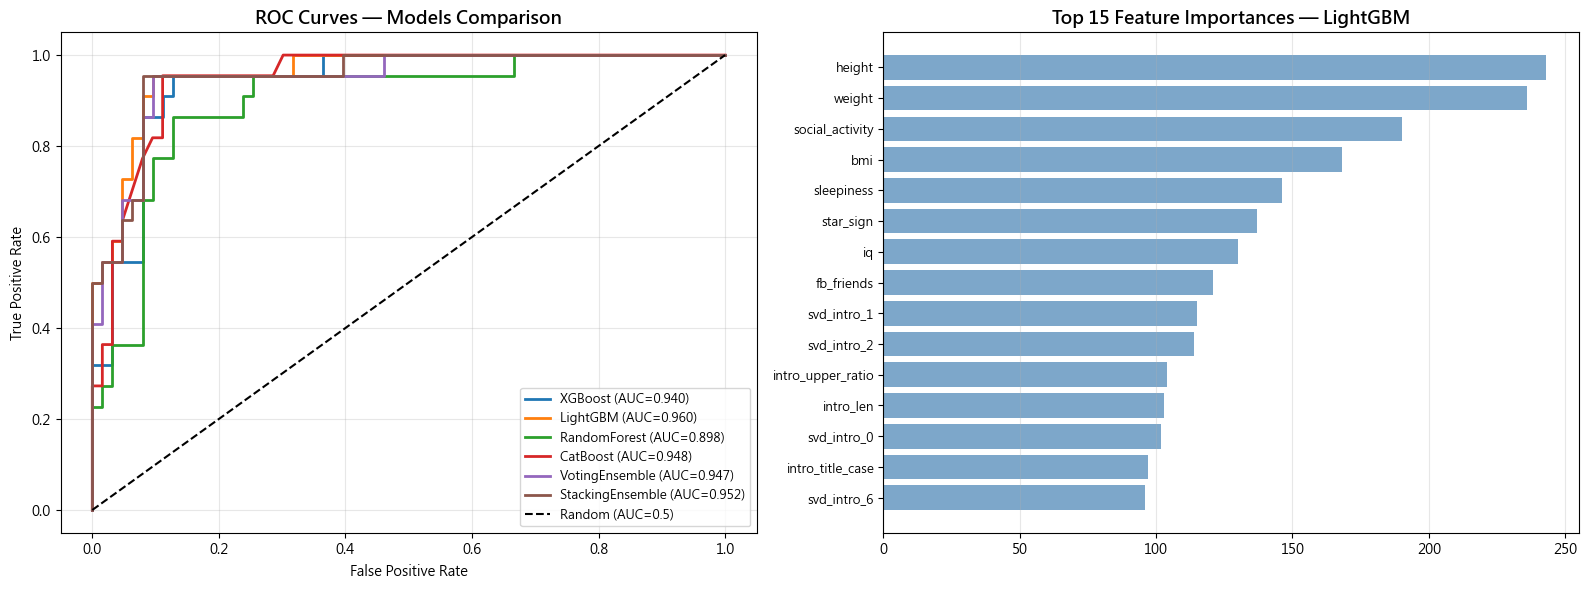

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curves (Fixed: Categories Target Encoded, no CatBoost special rule)
for name, model in trained_models.items():
    X_v = X_val_imputed.copy()
    prob = model.predict_proba(X_v)[:, 1]
    fpr, tpr, _ = roc_curve(y_val_bin, prob)
    axes[0].plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc(fpr,tpr):.3f})")

axes[0].plot([0,1],[0,1],'k--', label='Random (AUC=0.5)')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — Models Comparison', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# Feature Importance (Best Model)
if hasattr(best_model, 'feature_importances_'):
    imps = best_model.feature_importances_
    idx  = np.argsort(imps)[-15:]
    axes[1].barh(range(len(idx)), imps[idx], color='steelblue', alpha=0.7)
    axes[1].set_yticks(range(len(idx)))
    axes[1].set_yticklabels([X_proc.columns[i] for i in idx], fontsize=9)
    axes[1].set_title(f'Top 15 Feature Importances — {best_name}', fontsize=13, fontweight='bold')
    axes[1].grid(axis='x', alpha=0.3)
else:
    axes[1].text(0.5, 0.5, f'Feature importance\nnot available for {best_name}',
                 ha='center', va='center', fontsize=12, transform=axes[1].transAxes)

plt.tight_layout(); plt.show()


## 9. Stratified 5-Fold Cross-Validation

To reduce variance from a single train/val split, stratified 5-fold CV is applied.
SMOTE is applied **within each fold** via `ImbPipeline` — preventing data leakage from oversampling.
Both individual models and ensemble methods are evaluated.

In [14]:
# Fix: Process SMOTE within cross-val fold (ImbPipeline)
# And include CatBoost (can be passed cleanly as it is encoded)
from imblearn.pipeline import Pipeline as ImbPipeline

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_results = {}

def make_smote_pipe(model):
    return ImbPipeline([
        ('target_enc', KFoldTargetEncoder(cols=cat_cols)),  
        ('imputer', SimpleImputer(strategy='median')),
        ('smote',   SMOTE(random_state=RANDOM_SEED, k_neighbors=5)),
        ('model',   model)
    ])

cv_models = {
    'XGBoost':      make_smote_pipe(make_xgb()),
    'LightGBM':     make_smote_pipe(make_lgb()),
    'RandomForest': make_smote_pipe(make_rf()),
}
if HAS_CAT:
    cv_models['CatBoost'] = make_smote_pipe(make_cat())

for name, pipe in cv_models.items():
    print(f"{name}:")
    auc_scores = cross_val_score(pipe, X_proc, y_bin_all,
                                 cv=skf, scoring='roc_auc', n_jobs=-1)
    f1_scores  = cross_val_score(pipe, X_proc, y_bin_all,
                                 cv=skf, scoring='f1_macro', n_jobs=-1)
    cv_results[name] = {
        'roc_auc_mean': auc_scores.mean(), 'roc_auc_std': auc_scores.std(),
        'f1_macro_mean': f1_scores.mean(), 'f1_macro_std': f1_scores.std()
    }
    acc_scores = cross_val_score(pipe, X_proc, y_bin_all,
                                 cv=skf, scoring='accuracy', n_jobs=-1)
    print(f"  Accuracy: {acc_scores.mean():.4f} ± {acc_scores.std():.4f}")
    print(f"  ROC-AUC: {auc_scores.mean():.4f} ± {auc_scores.std():.4f}")
    print(f"  F1-Macro: {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")


XGBoost:
  Accuracy: 0.8653 ± 0.0239
  ROC-AUC: 0.9036 ± 0.0491
  F1-Macro: 0.8213 ± 0.0341
LightGBM:
  Accuracy: 0.8582 ± 0.0106
  ROC-AUC: 0.9087 ± 0.0527
  F1-Macro: 0.8061 ± 0.0106
RandomForest:
  Accuracy: 0.8464 ± 0.0305
  ROC-AUC: 0.8755 ± 0.0443
  F1-Macro: 0.7884 ± 0.0373
CatBoost:
  Accuracy: 0.8629 ± 0.0283
  ROC-AUC: 0.8975 ± 0.0517
  F1-Macro: 0.8124 ± 0.0410


In [15]:
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from imblearn.pipeline import Pipeline as ImbPipeline

# 1. Prepare evaluators list (use previously defined functions)
ens_estimators = []
if HAS_XGB: ens_estimators.append(('xgb', make_xgb()))
if HAS_LGB: ens_estimators.append(('lgb', make_lgb()))
ens_estimators.append(('rf', make_rf()))
if HAS_CAT: ens_estimators.append(('cat', make_cat()))

# 2. Define Stacking and Voting models
voting_model = VotingClassifier(estimators=ens_estimators, voting='soft', n_jobs=-1)

stacking_model = StackingClassifier(
    estimators=ens_estimators,
    final_estimator=meta_learner,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    stack_method='predict_proba',
    n_jobs=-1
)

# 3. Define evaluating list
ensemble_eval_models = {
    'VotingEnsemble': voting_model,
    'StackingEnsemble': stacking_model
}

print("Start Cross-Validation metrics (Accuracy, ROC-AUC, F1-Macro)...")
print("-" * 50)

for name, model in ensemble_eval_models.items():
    # Encapsulate model into a Pipeline containing SMOTE
    pipe = make_smote_pipe(model)
    
    print(f"Processing {name}...")
    
    # Calculate 3 metrics separately
    acc_scores = cross_val_score(pipe, X_proc, y_bin_all, cv=skf, scoring='accuracy', n_jobs=-1)
    auc_scores = cross_val_score(pipe, X_proc, y_bin_all, cv=skf, scoring='roc_auc', n_jobs=-1)
    f1_scores = cross_val_score(pipe, X_proc, y_bin_all, cv=skf, scoring='f1_macro', n_jobs=-1)
    
    print(f"{name} Cross Val Result:")
    print(f"  - Accuracy: {acc_scores.mean():.4f} ± {acc_scores.std():.4f}")
    print(f"  - ROC-AUC:  {auc_scores.mean():.4f} ± {auc_scores.std():.4f}")
    print(f"  - F1-Macro: {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")
    print("-" * 50)

Start Cross-Validation metrics (Accuracy, ROC-AUC, F1-Macro)...
--------------------------------------------------
Processing VotingEnsemble...
VotingEnsemble Cross Val Result:
  - Accuracy: 0.8701 ± 0.0243
  - ROC-AUC:  0.9012 ± 0.0529
  - F1-Macro: 0.8247 ± 0.0348
--------------------------------------------------
Processing StackingEnsemble...
StackingEnsemble Cross Val Result:
  - Accuracy: 0.8676 ± 0.0170
  - ROC-AUC:  0.9025 ± 0.0533
  - F1-Macro: 0.8196 ± 0.0255
--------------------------------------------------


## 10. Generate Kaggle Submission File

The best-performing model (`StackingEnsemble`) is used for final predictions.
- **Threshold tuning** — Optimal classification threshold is selected by sweeping `[0.25, 0.75]` on the validation set.
- Predictions are mapped back to original label encoding and exported as a CSV.

In [16]:
best_name = "StackingEnsemble"
best_model = trained_models[best_name]

# ── Step 1: Find best threshold (using best_model, only saw train) ───
probs_val_for_thresh = best_model.predict_proba(X_val_imputed)[:, 1]
best_thresh, best_acc = 0.5, 0
for t in np.arange(0.25, 0.75, 0.01):
    preds = (probs_val_for_thresh >= t).astype(int)
    acc = accuracy_score(y_val_bin, preds)
    if acc > best_acc:
        best_acc, best_thresh = acc, t
print(f"Best threshold: {best_thresh:.2f}, Val Accuracy: {best_acc:.4f}")
print(f"Using model: {best_name}")

# ── Step 2: Train final model across ALL data (same architecture) ────
# Whole data Target Encoding for final model
y_bin_all = (y == 2).astype(int)
te_final = KFoldTargetEncoder(cols=cat_cols)
X_proc_encoded = pd.DataFrame(
    te_final.fit_transform(X_proc, y_bin_all),
    columns=X_proc.columns
)
imputer_final = SimpleImputer(strategy='median')
X_all_imputed = pd.DataFrame(
    imputer_final.fit_transform(X_proc_encoded),   # X_proc encoded globally
    columns=X_proc.columns
)


# Dynamically match best architecture
model_factory = {
    'XGBoost':        make_xgb,
    'LightGBM':       make_lgb,
    'RandomForest':   make_rf,
    'CatBoost':       make_cat,
    'VotingEnsemble': lambda: VotingClassifier(
        estimators=[('xgb', make_xgb()), ('lgb', make_lgb()),
                    ('rf', make_rf()), ('cat', make_cat())],
        voting='soft', n_jobs=-1
    ),
    'StackingEnsemble': lambda: StackingClassifier(
        estimators=[('xgb', make_xgb()), ('lgb', make_lgb()),
                    ('rf', make_rf()), ('cat', make_cat())],
        final_estimator=LogisticRegression(C=1.0, max_iter=1000,
                                           class_weight='balanced',
                                           random_state=RANDOM_SEED),
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
        stack_method='predict_proba', n_jobs=-1
    ),
}

final_model = model_factory[best_name]()

# Whole data SMOTE retrain
sm_final = SMOTE(random_state=RANDOM_SEED, k_neighbors=5)
X_all_sm, y_all_sm = sm_final.fit_resample(X_all_imputed, y_bin_all)

final_model.fit(X_all_sm, y_all_sm)
print(f"✓ Full data retrain completed (Architecture: {best_name})")

# ── Step 3: Predict against Test set ────────────────────────────
X_test_final = pd.DataFrame(
    imputer_final.transform(
        te_final.transform(X_test_proc)
    ),
    columns=X_test_proc.columns
)
probs_test = final_model.predict_proba(X_test_final)[:, 1]
raw_pred   = (probs_test >= best_thresh).astype(int)
test_pred  = raw_pred + 1
submission = pd.DataFrame({'id': df_test['id'], 'gender': test_pred})
print(f"Submission gender distribution: {submission['gender'].value_counts().to_dict()}")

SUB_PATH = 'submission.csv'
submission.to_csv(SUB_PATH, index=False, encoding='utf-8')
print(f"✓ Successfully saved to {SUB_PATH}")
print(submission.head(10).to_string(index=False))

Best threshold: 0.29, Val Accuracy: 0.9294
Using model: StackingEnsemble
✓ Full data retrain completed (Architecture: StackingEnsemble)
Submission gender distribution: {1: 289, 2: 137}
✓ Successfully saved to submission.csv
 id  gender
  1       1
  2       1
  3       2
  4       1
  5       2
  6       1
  7       1
  8       1
  9       2
 10       1


## 11. Summary & Next Steps

### Completed
| Item | Status |
|------|--------|
| Data leakage fix (`OrdinalEncoder` on train only) | ✅ |
| `self_intro` text feature extraction (8 features) | ✅ |
| `sleepiness` / `yt` outlier tagging | ✅ |
| CatBoost added | ✅ |
| VotingEnsemble double-fit fix | ✅ |
| Stacking Ensemble (XGB + LGB + RF + CatBoost → LR) | ✅ |
| Optuna search expanded to 50 trials | ✅ |
